Dataset loaded successfully!

First 5 rows:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset shape:
(150, 6)

Column names:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

Class distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Missing values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Training samples: 120
Testing samples: 30

Model trained successfull

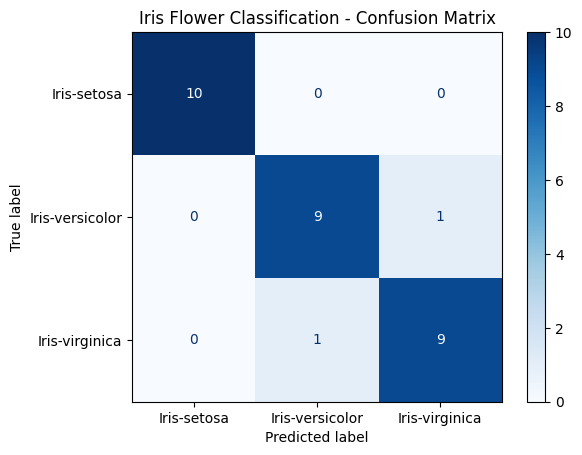


New Flower Prediction:
Iris-setosa


In [1]:
# ============================================
# IRIS FLOWER CLASSIFICATION PROJECT
# ============================================

# Step 1: Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ============================================
# Step 2: Load the dataset
# ============================================

# Make sure Iris.csv is in the same folder as this Python file
data = pd.read_csv("Iris.csv")

print("Dataset loaded successfully!")
print("\nFirst 5 rows:")
print(data.head())

# ============================================
# Step 3: Explore the dataset
# ============================================

print("\nDataset shape:")
print(data.shape)

print("\nColumn names:")
print(data.columns)

print("\nClass distribution:")
print(data["Species"].value_counts())

# Check missing values
print("\nMissing values:")
print(data.isnull().sum())

# ============================================
# Step 4: Select input features and target
# ============================================

# Input features
X = data[
    [
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ]
]

# Target/output
y = data["Species"]

# ============================================
# Step 5: Split data into training and testing
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

# ============================================
# Step 6: Build the Machine Learning Model
# ============================================

# StandardScaler normalizes the input values.
# Logistic Regression is used for classification.

model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=200))
])

# ============================================
# Step 7: Train the model
# ============================================

model.fit(X_train, y_train)

print("\nModel trained successfully!")

# ============================================
# Step 8: Make predictions
# ============================================

y_pred = model.predict(X_test)

# ============================================
# Step 9: Calculate accuracy
# ============================================

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:")
print(f"{accuracy * 100:.2f}%")

# ============================================
# Step 10: Classification Report
# ============================================

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ============================================
# Step 11: Confusion Matrix
# ============================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Display confusion matrix graph
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Iris Flower Classification - Confusion Matrix")
plt.show()

# ============================================
# Step 12: Test the model with new data
# ============================================

# Example flower measurements:
# Sepal Length = 5.1
# Sepal Width  = 3.5
# Petal Length = 1.4
# Petal Width  = 0.2

new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=[
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ]
)

prediction = model.predict(new_flower)

print("\nNew Flower Prediction:")
print(prediction[0])